### Binary Traffic Sign Classification

This is our first notebook on neural networks. We will start by building a simple neural network that will help us to classify two types of traffic signs. The signs used in this lesson are a processed subset from the famous German Traffic Sign Recognition Database (GTSRB) that can be downloaded [here]().

In [1]:
import os
import cv2
from time import time
from pathlib import Path
import numpy as np
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

from matplotlib import pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = [15, 6]

#### Data Loading

Let's now load the data to see what we are dealing with.

In [3]:
data_path = Path("./data/")

In [4]:
def plot_ds(ds, rows=3, cols=3):
    for images, labels in ds.take(1):
        for i in range(rows * cols):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")
            plt.title(ds.class_names[labels[i]])
            plt.axis("off")

In [5]:
def load_ds(data_path, subset):
    return tf.keras.utils.image_dataset_from_directory(
        data_path,
        color_mode='grayscale',
        image_size=(28, 28),
        validation_split=0.2,
        subset=subset,
        seed=0,
        batch_size=32,
    )

In [6]:
def get_classes_counts(ds):
    classes = ds.class_names
    values, counts = np.unique(np.concatenate([item[1].numpy() for item in ds]), return_counts=True)

    for value, count in zip(values, counts):
        print(f"{classes[value]}: {count} samples")

In [7]:
def plot_predictions(ds, model):
    images, labels = next(iter(ds))
    predictions = model.predict(images)

    for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
        plt.subplot(2, 5, cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
        plt.title(str(labels[idx].numpy()) + " - " + str(predictions[idx][0]))
        plt.axis(False)

In [8]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))
    plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
    plt.xlabel('epoch'), plt.ylabel('loss');

In [9]:
train_ds = load_ds(data_path, "training")

Found 4470 files belonging to 2 classes.
Using 3576 files for training.


I0000 00:00:1760289893.468477  387170 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8970 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
val_ds = load_ds(data_path, "validation")


Found 4470 files belonging to 2 classes.
Using 894 files for validation.


2025-10-12 20:24:55.587091: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


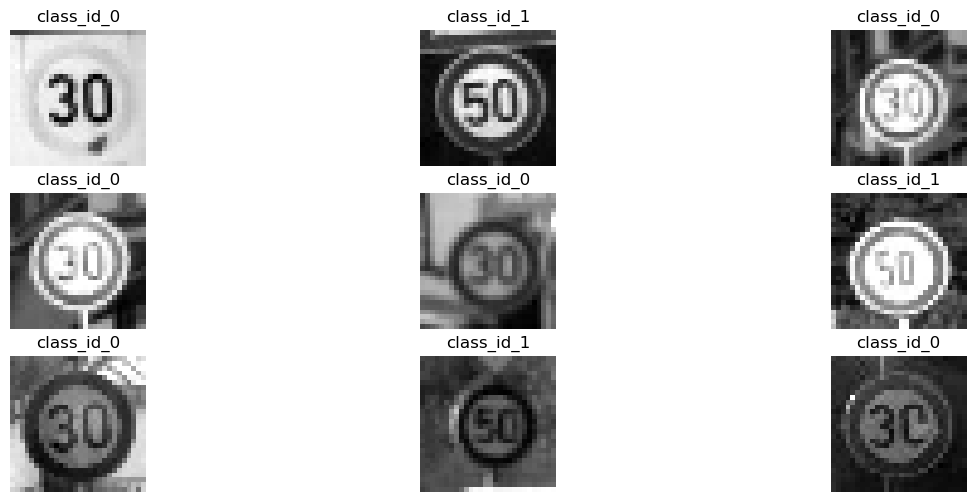

In [11]:
plot_ds(val_ds)

In [12]:
get_classes_counts(train_ds)

class_id_0: 1799 samples
class_id_1: 1777 samples


2025-10-12 20:24:56.057101: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
get_classes_counts(val_ds)

class_id_0: 421 samples
class_id_1: 473 samples


#### Building the Neural Network

Let's now build our first (and yes, very simple) neural network using Tensorflow. For that, we will need a couple of new imports.

The following netowork will consist of only one single neuron. It is a very tiny network (not even a network, strictly speaking :-) ) and yet it can be quite powerful.

In [14]:
num_classes = len(train_ds.class_names)

model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(28, 28)),
  tf.keras.layers.Rescaling(1./255),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1, activation='linear'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
  optimizer='adam',
  loss="mse",
  metrics=['accuracy'],
)

Epoch 1/10


2025-10-12 20:24:57.685721: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c10500047e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-12 20:24:57.685750: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-10-12 20:24:57.704958: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-12 20:24:57.759576: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4573 - loss: 0.4310

I0000 00:00:1760289898.034782  387279 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4961 - loss: 0.3489 - val_accuracy: 0.5358 - val_loss: 0.2758
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5973 - loss: 0.2560 - val_accuracy: 0.6432 - val_loss: 0.2211
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6854 - loss: 0.2033 - val_accuracy: 0.7125 - val_loss: 0.1879
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7402 - loss: 0.1741 - val_accuracy: 0.6409 - val_loss: 0.2192
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7626 - loss: 0.1590 - val_accuracy: 0.7808 - val_loss: 0.1556
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8079 - loss: 0.1391 - val_accuracy: 0.8266 - val_loss: 0.1339
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8305 - loss: 0.1300 - val_accuracy: 0.8378 - val_loss: 0.1281
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8568 - loss: 0.1185 - val_accuracy: 0.8613 - val

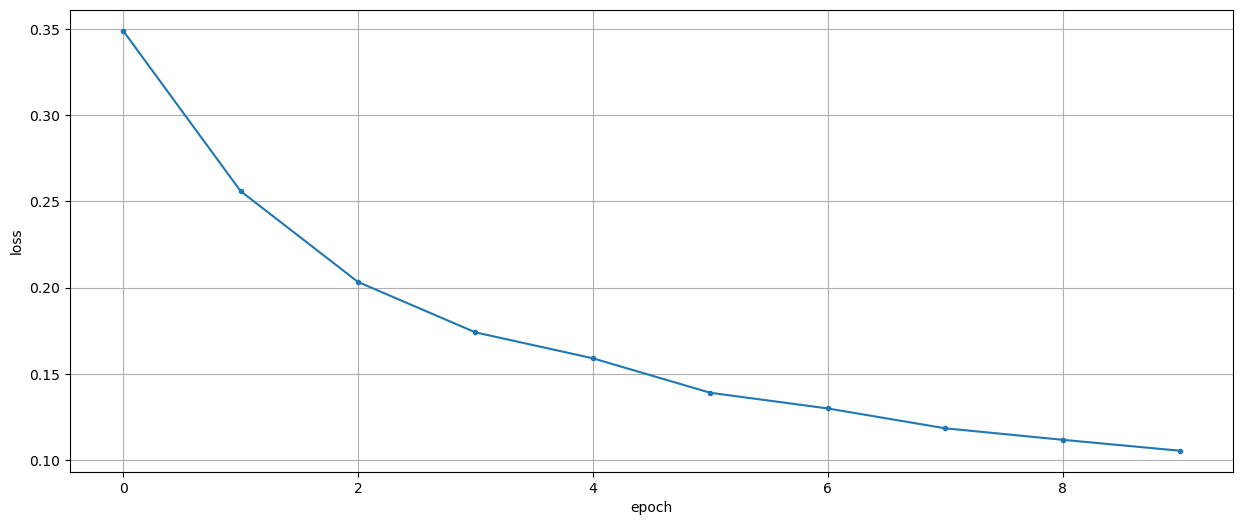

In [16]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


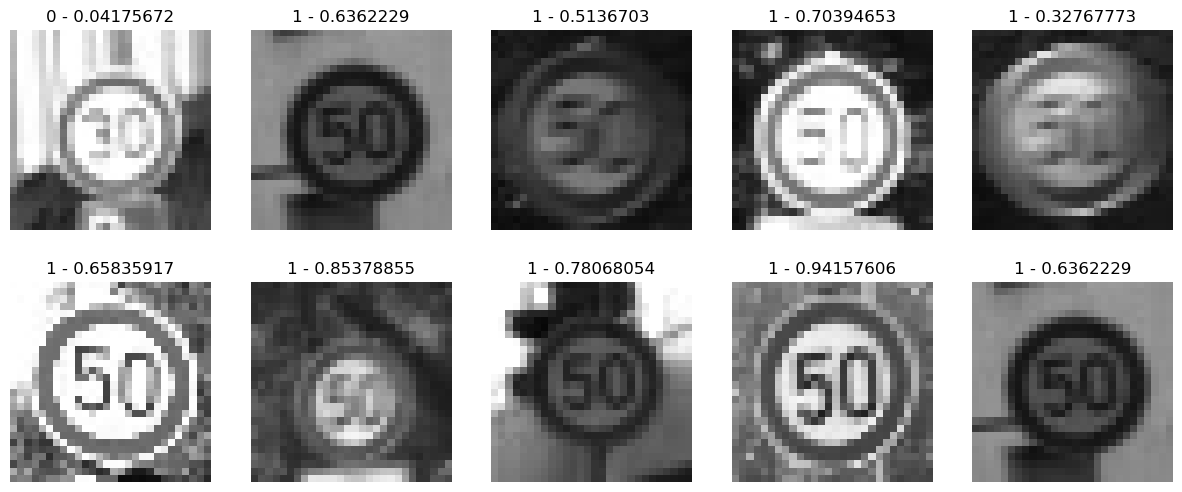

In [17]:
plot_predictions(val_ds, model)

### More complex model

In [18]:
model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(28, 28)),
  tf.keras.layers.Rescaling(1./255),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(1, activation='linear'),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


2025-10-12 20:25:04.238414: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-12 20:25:05.811444: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_293', 8 bytes spill stores, 8 bytes spill loads

2025-10-12 20:25:06.255666: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_293', 272 bytes spill stores, 272 bytes spill loads



112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5965 - loss: 0.3065 - val_accuracy: 0.6320 - val_loss: 0.2189
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7388 - loss: 0.1705 - val_accuracy: 0.6913 - val_loss: 0.2293
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8163 - loss: 0.1379 - val_accuracy: 0.8479 - val_loss: 0.1316
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8638 - loss: 0.1184 - val_accuracy: 0.8535 - val_loss: 0.1243
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9035 - loss: 0.0995 - val_accuracy: 0.9251 - val_loss: 0.0937
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9105 - loss: 0.1007 - val_accuracy: 0.7383 - val_loss: 0.2179
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9281 - loss: 0.0920 - val_accuracy: 0.9128 - val_loss: 0.1032
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9402 - loss: 0.0865 - val_accuracy: 0.9262 - val

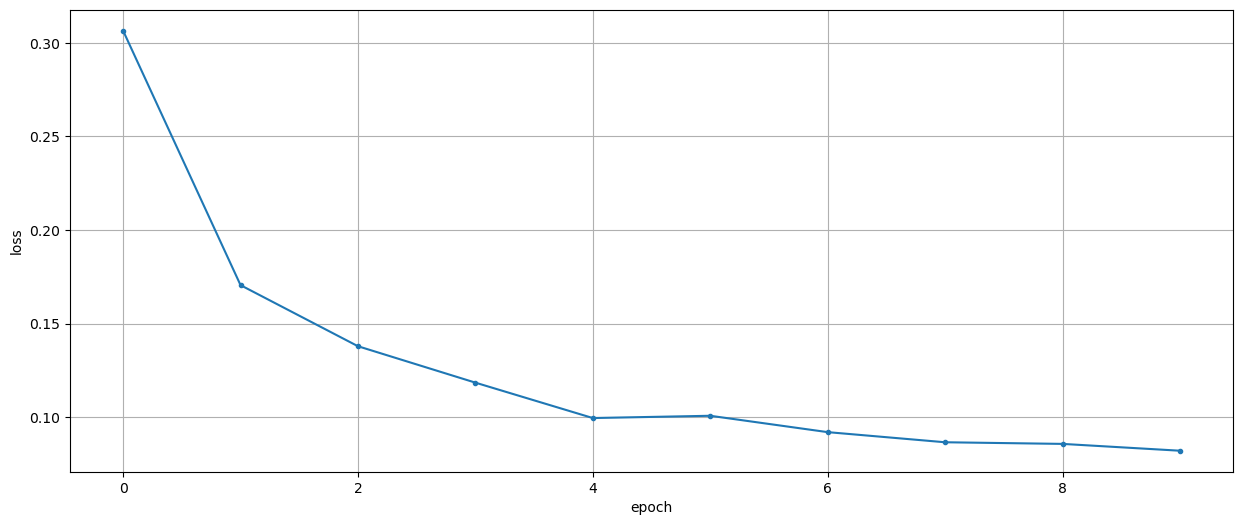

In [19]:
model.compile(
  optimizer='adam',
  loss="mse",
  metrics=['accuracy'],
)
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step


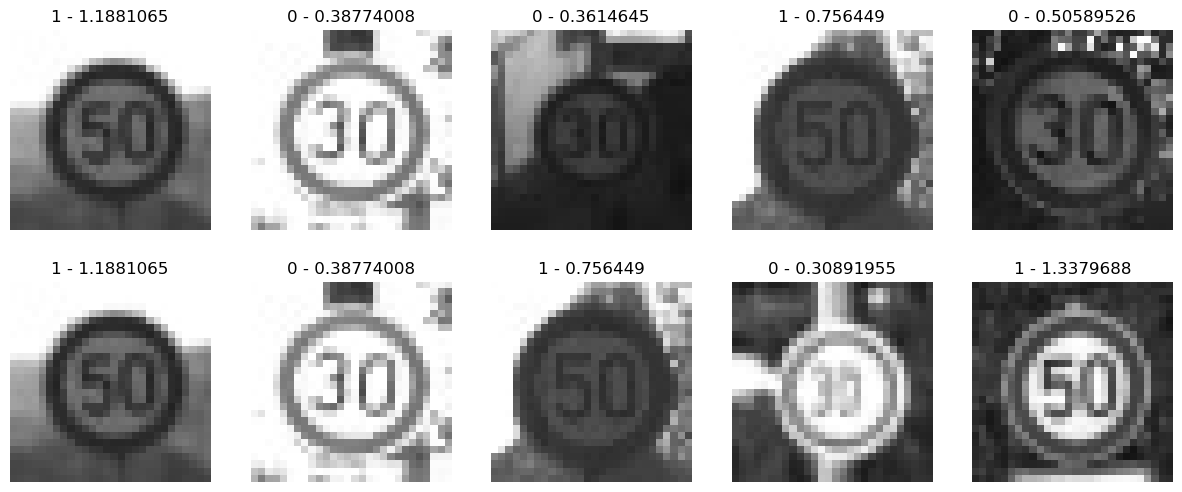

In [20]:
plot_predictions(val_ds, model)

Adding new layer with 128 neurons and relu activation gave us validation accuracy of 94.07% (single neuron accuracy was 86.91%)